<a href="https://colab.research.google.com/github/guilhermek32/ListaVisao-2026.1/blob/Lista-04/q2_partA_partB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install ultralytics opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.7 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Processando o vídeo... Por favor, aguarde.
Item (a) concluído! Vídeo salvo em: Q2A_bridge_detected.avi
Item (b) concluído! Gráfico salvo em: Q2B_vehicle_count_graph.png


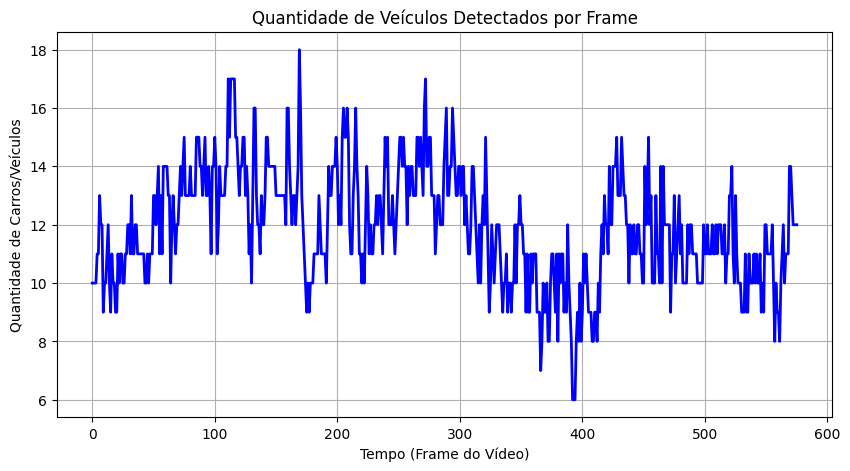

In [3]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
VEHICLE_CLASSES = [2, 3, 5, 7]

video_path = "bridge.mp4"

# Verificação extra
if not os.path.exists(video_path):
    print(
        f"Erro: O arquivo '{video_path}' não foi encontrado no diretório atual: {os.getcwd()}"
    )
    exit()

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f"Erro ao abrir o arquivo de vídeo '{video_path}' pelo OpenCV.")
    exit()

# Obter propriedades do vídeo
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Configurar o arquivo de saída
output_path = "Q2A_bridge_detected.avi"
fourcc = cv2.VideoWriter_fourcc(*"XVID")
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

frames_list = []
vehicle_count_list = []
frame_idx = 0

print("Processando o vídeo... Por favor, aguarde.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break  # Sai do loop se o vídeo acabar ou falhar no primeiro frame

    # Realizar a detecção
    results = model(frame, classes=VEHICLE_CLASSES, verbose=False)[0]
    num_vehicles = len(results.boxes)

    # Plotar as bounding boxes
    annotated_frame = results.plot()

    # Adicionar texto no frame
    cv2.putText(
        annotated_frame,
        f"Veiculos: {num_vehicles}",
        (30, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2,
    )

    # Salvar frame e dados
    out.write(annotated_frame)
    frames_list.append(frame_idx)
    vehicle_count_list.append(num_vehicles)

    frame_idx += 1

cap.release()
out.release()
cv2.destroyAllWindows()

# Verificar se algum frame chegou a ser processado
if len(frames_list) == 0:
    print(
        "Erro: Nenhum frame foi processado. O loop de leitura falhou imediatamente."
    )
else:
    print(f"Item (a) concluído! Vídeo salvo em: {output_path}")

    # Gerar e plotar o gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(frames_list, vehicle_count_list, color="blue", linewidth=2)
    plt.title("Quantidade de Veículos Detectados por Frame")
    plt.xlabel("Tempo (Frame do Vídeo)")
    plt.ylabel("Quantidade de Carros/Veículos")
    plt.grid(True)

    graph_path = "Q2B_vehicle_count_graph.png"
    plt.savefig(graph_path)
    print(f"Item (b) concluído! Gráfico salvo em: {graph_path}")
    plt.show()